In [13]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [14]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [15]:
# Unzip data
!unzip -q "image dataset.zip" -d /content/my_dataset

In [16]:
import os

# Check the subfolders or image files
dataset_path = '/content/my_dataset'
print(os.listdir(dataset_path))

# Input image dimensions
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 2


['image dataset']


In [17]:
# STEP 4: DATA PREPROCESSING & AUGMENTATION
# We split the data automatically into Training (80%) and Validation (20%)
# Training Data Generator (Includes Augmentation to prevent overfitting)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to [0, 1]
    rotation_range=20,        # Random rotations
    width_shift_range=0.2,    # Random horizontal shift
    height_shift_range=0.2,   # Random vertical shift
    shear_range=0.2,          # Random shear
    zoom_range=0.2,           # Random zoom
    horizontal_flip=True,     # Random horizontal flip
    fill_mode='nearest',
    validation_split=0.2      # Reserve 20% for validation
)

In [18]:
# Validation Data Generator (Only rescaling, NO augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

print("Loading data from directories...")

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',      # Binary classification
    subset='training',        # Set as training data
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',      # Set as validation data
    shuffle=False
)

print(f"\nClass Indices: {train_generator.class_indices}")

Loading data from directories...
Found 40 images belonging to 1 classes.
Found 10 images belonging to 1 classes.

Class Indices: {'image dataset': 0}


In [19]:
# STEP 5: BUILD THE CNN MODEL
model = Sequential()

# Block 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 4
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten and Dense Layers
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5)) # Prevent overfitting
model.add(Dense(1, activation='sigmoid')) # Sigmoid for binary output

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265,729 (73.49 MB)

 Trainable params: 19,264,769 (73.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [20]:
#STEP 6: CALLBACKS (Learning Rate Decay & Early Stopping)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,               # Stop training if val_loss doesn't improve for 5 epochs
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,               # Reduce LR by 80% if plateau
    patience=3,
    min_lr=1e-6
)

# STEP 7: TRAIN THE MODEL
print("\nStarting Training...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Starting Training...
Epoch 1/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.1562 - loss: 3.1684 - val_accuracy: 1.0000 - val_loss: 0.0643 - learning_rate: 0.0010
Epoch 2/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8750 - loss: 1.9186 - val_accuracy: 1.0000 - val_loss: 0.1265 - learning_rate: 0.0010


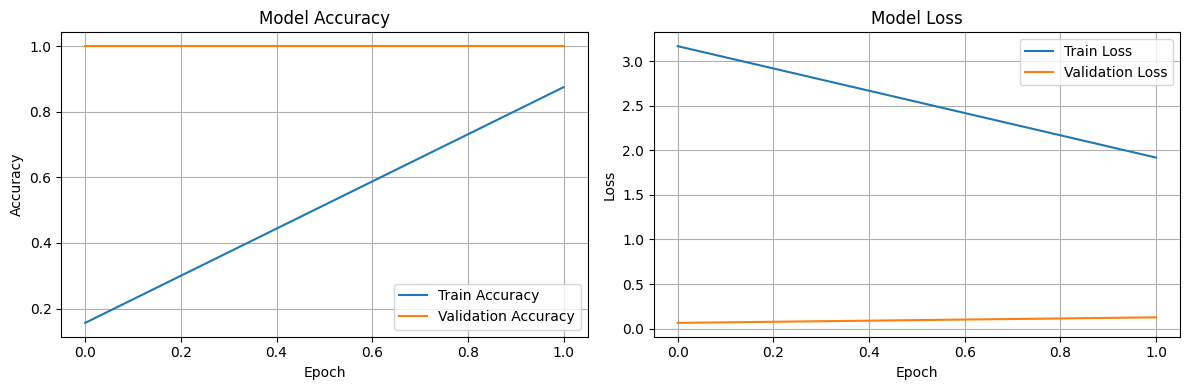

In [21]:
# STEP 8: VISUALIZATION (Accuracy & Loss)
plt.figure(figsize=(12, 4))

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [28]:
# STEP 9: EVALUATE ON VALIDATION DATA
print("\nEvaluating on Validation Set...")
validation_generator.reset()  # Important to reset the generator pointer
loss, acc = model.evaluate(validation_generator, verbose=0)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {acc:.4f}")


# STEP 10: PREDICT ON A SINGLE CUSTOM IMAGE
def predict_single_image(img_path):
    try:

        # Load and preprocess image
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) # Create a batch of size 1
        img_array /= 255.0 # Normalize

# Get prediction
        prediction = model.predict(img_array, verbose=0)[0][0]

        # Decode binary result based on generator indices
        # 0 = Class 0, 1 = Class 1
        classes = list(train_generator.class_indices.keys())
        predicted_class = classes[int(round(prediction))]
        confidence = prediction if predicted_class == classes[1] else 1 - prediction

        # Plot the image
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {predicted_class} (Confidence: {confidence:.2f})")
        plt.show()

        return predicted_class, confidence

    except Exception as e:
        print(f"Error loading image: {e}")


Evaluating on Validation Set...
Validation Loss: 0.0643
Validation Accuracy: 1.0000



Generating classification visualization on Validation Set...


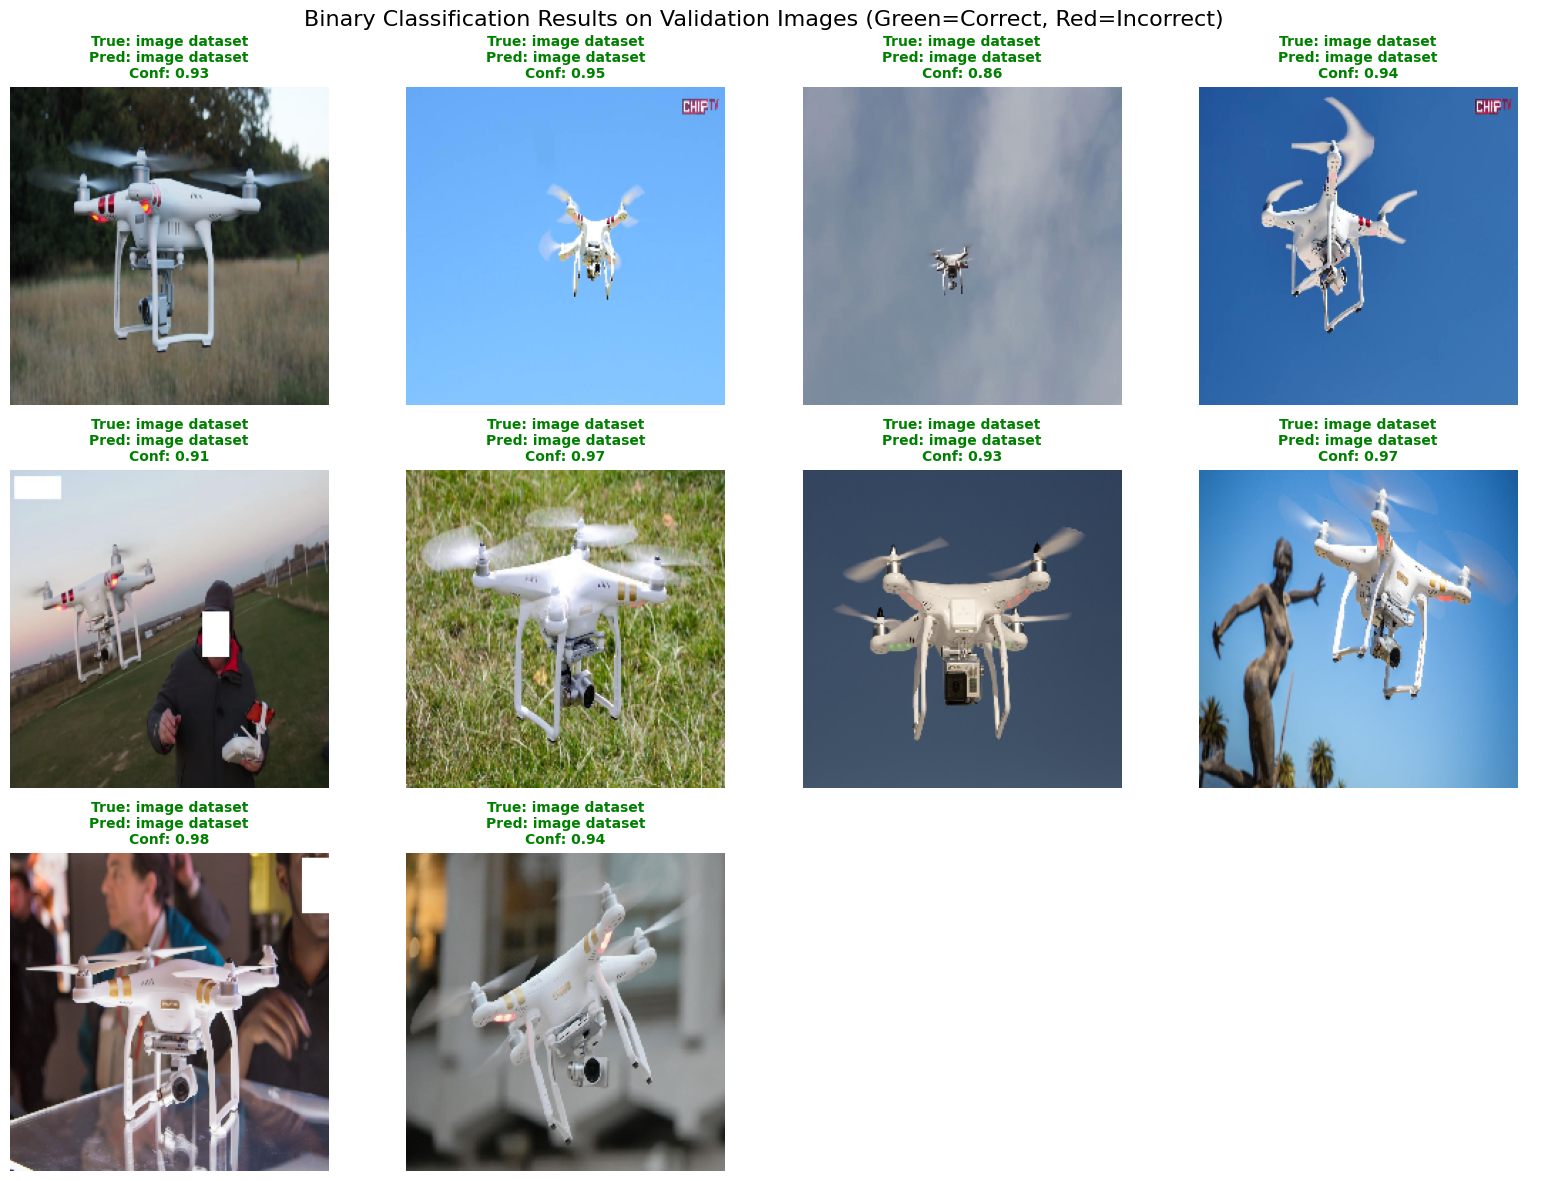

In [30]:
# STEP 11: VISUALIZE CLASSIFICATION RESULTS ON VALIDATION IMAGES
# ==========================================
import random

print("\nGenerating classification visualization on Validation Set...")

# Get the class names (e.g., ['birds', 'drones'])
class_labels = list(train_generator.class_indices.keys())

# Reset the validation generator to start from the beginning
validation_generator.reset()

# Get a batch of images and labels
# Note: This grabs the first batch. For random sampling, we manually pull indices later.
x_val_batch, y_val_batch = next(validation_generator)

# Make predictions on this batch
predictions = model.predict(x_val_batch, verbose=0)
predicted_classes = (predictions > 0.5).astype("int32").flatten()

# Select 12 random indices from the batch to display
num_samples = min(12, len(x_val_batch))
random_indices = random.sample(range(len(x_val_batch)), num_samples)

# Set up the plot grid (3 rows, 4 columns)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, idx in enumerate(random_indices):
    ax = axes[i]

    # Get the image data (denormalize slightly for better viewing if needed, but 0-1 is fine)
    img = x_val_batch[idx]

    # Get true and predicted labels
    true_label_idx = int(y_val_batch[idx])
    pred_label_idx = predicted_classes[idx]
    confidence = predictions[idx][0] if pred_label_idx == 1 else 1 - predictions[idx][0]

    true_label = class_labels[true_label_idx]
    pred_label = class_labels[pred_label_idx]

    # Determine color: Green if correct, Red if incorrect
    color = 'green' if true_label_idx == pred_label_idx else 'red'

    # Display image
    ax.imshow(img)
    ax.axis('off')

    # Title with True, Predicted, and Confidence
    ax.set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}",
                 color=color, fontsize=10, fontweight='bold')

# Hide any unused subplots if batch size < 12
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Binary Classification Results on Validation Images (Green=Correct, Red=Incorrect)', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()


Generating Confusion Matrix...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


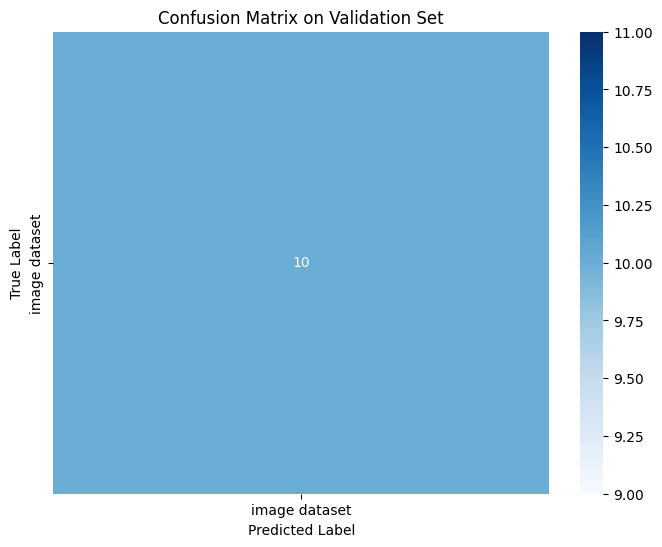


Classification Report:
               precision    recall  f1-score   support

image dataset       1.00      1.00      1.00        10

     accuracy                           1.00        10
    macro avg       1.00      1.00      1.00        10
 weighted avg       1.00      1.00      1.00        10



In [31]:
# STEP 12: CONFUSION MATRIX & METRICS SUMMARY
# ==========================================
print("\nGenerating Confusion Matrix...")

# Reset generator and get all validation predictions
validation_generator.reset()
y_true = validation_generator.classes
# Get all predictions for the validation set
predictions_all = model.predict(validation_generator, verbose=0)
y_pred = (predictions_all > 0.5).astype("int32").flatten()

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix on Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))